# Занятие 03. Дерево решений по внешнему набору данных: ElectricMotorTemperature, Zenodo TSML Archive

## Теоретический блок

Классификация (classification) - задача отнесения наблюдения к одному из
заранее заданных классов. В данном блокноте целевая переменная
`is_allowed` кодирует условно допустимый режим: целевая температура временного фрагмента не выше учебного порога.
Дерево решений (Decision Tree) используется как интерпретируемая модель,
поскольку его правила можно записать в виде пороговых инженерных условий.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Не найден корень проекта appai_lab.")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_FILE = DATA_DIR / "external/zenodo_motor_temperature_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "external/zenodo_motor_temperature_diagnostics.csv"
METADATA_FILE = DATA_DIR / "external/zenodo_motor_temperature_metadata.md"
FALLBACK_FEATURES_FILE = DATA_DIR / "practice_02_motor_efficiency_features.csv"
FALLBACK_DIAGNOSTICS_FILE = DATA_DIR / "practice_02_motor_efficiency_diagnostics.csv"

RANDOM_STATE = 20260507
GROUP_COLUMN = "profile_id"
TIME_COLUMN = "time_index"
DATASET_ID = "zenodo_motor_temperature"
DATASET_TITLE = "ElectricMotorTemperature, Zenodo TSML Archive"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


def load_external_or_fallback():
    if FEATURES_FILE.exists() and DIAGNOSTICS_FILE.exists():
        features = pd.read_csv(FEATURES_FILE)
        diagnostics = pd.read_csv(DIAGNOSTICS_FILE)
        source_status = "external"
    else:
        features = pd.read_csv(FALLBACK_FEATURES_FILE)
        diagnostics = pd.read_csv(FALLBACK_DIAGNOSTICS_FILE)
        source_status = "fallback_base"
    full = features.merge(diagnostics, on="sample_id", how="left", validate="one_to_one")
    return features, diagnostics, full, source_status


def plot_correlation_heatmap(data, columns, title):
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(max(7, 0.75 * len(columns)), max(5, 0.65 * len(columns))))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")
    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def group_holdout_split(data, group_column, test_share=0.25):
    groups = np.array(sorted(data[group_column].dropna().unique()))
    test_count = max(1, int(np.ceil(len(groups) * test_share)))
    test_groups = groups[-test_count:]
    test_mask = data[group_column].isin(test_groups)
    return data.index[~test_mask], data.index[test_mask], test_groups


features_df, diagnostics_df, full_df, source_status = load_external_or_fallback()
print("Источник данных:", source_status)
print("Файл признаков:", FEATURES_FILE if source_status == "external" else FALLBACK_FEATURES_FILE)
print("Размер feature-таблицы:", features_df.shape)
features_df.head()


Источник данных: external
Файл признаков: /mnt/f/projects/appai_lab/data/processed/external/zenodo_motor_temperature_features.csv
Размер feature-таблицы: (12000, 13)


,sample_id,profile_id,time_index,channel_00_mean,channel_01_mean,channel_02_mean,channel_03_mean,channel_04_mean,channel_05_mean,channel_00_trend,channel_01_trend,target_temperature_c,is_allowed
0,1,1000,0,-1.077220,1.367135,1.097118,-2.000468,25.905690,18.289637,0.012883,0.021129,54.556091,1
1,2,1000,1,127.949503,27.574080,-24.319673,-46.308822,28.158680,41.524931,5.868119,-28.250566,72.535668,1
2,3,1000,2,12.068943,0.870153,1.098589,-2.000007,22.730333,18.365001,0.016368,0.005058,27.399111,1
3,4,1000,3,126.008307,34.879808,-25.117721,-86.576199,27.708449,56.422220,-4.558056,10.908588,74.043505,1
4,5,1000,4,-0.396174,-0.748006,1.097415,-2.000649,24.450017,59.723624,0.029844,-0.074059,72.560170,1


In [2]:
classification_features = ['channel_00_mean', 'channel_01_mean', 'channel_02_mean', 'channel_03_mean', 'channel_04_mean', 'channel_05_mean', 'channel_00_trend', 'channel_01_trend']
classification_target = 'is_allowed'
forbidden_classification_features = set(['target_temperature_c', 'thermal_limit_target_temperature_c', 'is_allowed'])
leaked_classification_features = forbidden_classification_features & set(classification_features)
if leaked_classification_features:
    raise AssertionError(
        "Обнаружена утечка данных в classification_features: "
        f"{sorted(leaked_classification_features)}"
    )

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree

model_df = full_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=classification_features + [classification_target]
).copy()
train_idx, test_idx, test_groups = group_holdout_split(model_df, GROUP_COLUMN, test_share=0.25)
X_train = model_df.loc[train_idx, classification_features]
X_test = model_df.loc[test_idx, classification_features]
y_train = model_df.loc[train_idx, classification_target].astype(int)
y_test = model_df.loc[test_idx, classification_target].astype(int)

print("Тестовые группы:", test_groups)
print("Распределение классов в полной выборке:")
print(model_df[classification_target].value_counts().sort_index())


Тестовые группы: [2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018
 2019]
Распределение классов в полной выборке:
is_allowed
0    2400
1    9600
Name: count, dtype: int64


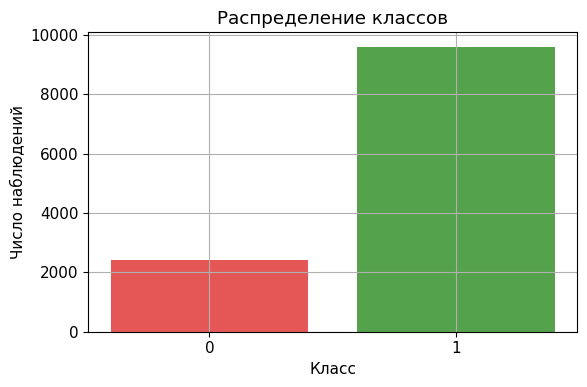

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
class_counts = model_df[classification_target].value_counts().sort_index()
ax.bar(class_counts.index.astype(str), class_counts.values, color=["#e45756", "#54a24b"][:len(class_counts)])
ax.set_xlabel("Класс")
ax.set_ylabel("Число наблюдений")
ax.set_title("Распределение классов")
plt.tight_layout()
plt.show()


In [4]:
def classification_metrics(y_true, y_pred):
    cm_local = confusion_matrix(y_true, y_pred, labels=[0, 1])
    not_allowed_total = cm_local[0].sum()
    dangerous_false_allowed_rate = cm_local[0, 1] / not_allowed_total if not_allowed_total > 0 else 0.0
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_not_allowed": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_not_allowed": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_not_allowed": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "dangerous_false_allowed_rate": dangerous_false_allowed_rate,
    }

majority_class = int(y_train.mode().iloc[0])
baseline_pred = np.full(len(y_test), majority_class, dtype=int)

tree_model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=8, random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

metrics_df = pd.DataFrame(
    [
        {"model": "majority_baseline", **classification_metrics(y_test, baseline_pred)},
        {"model": "strict_decision_tree", **classification_metrics(y_test, y_pred)},
    ]
).set_index("model")
metrics_df


,accuracy,precision_not_allowed,recall_not_allowed,f1_not_allowed,dangerous_false_allowed_rate
model,,,,,
majority_baseline,0.801333,0.000000,0.000000,0.000000,1.000000
strict_decision_tree,0.862333,0.670391,0.604027,0.635481,0.395973


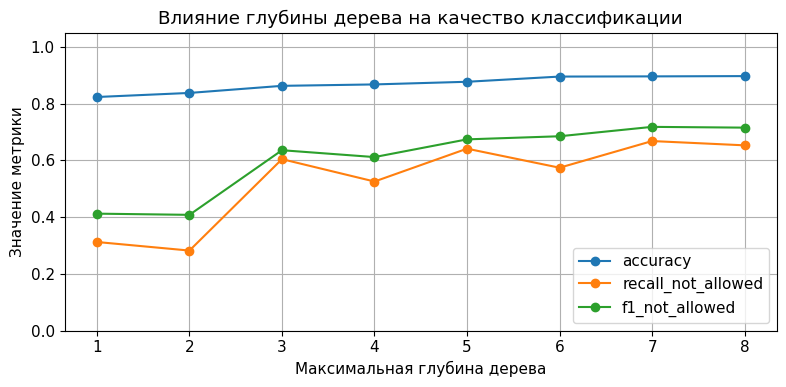

,accuracy,precision_not_allowed,recall_not_allowed,f1_not_allowed,dangerous_false_allowed_rate
max_depth,,,,,
1,0.823000,0.605863,0.312081,0.411960,0.687919
2,0.837333,0.736842,0.281879,0.407767,0.718121
3,0.862333,0.670391,0.604027,0.635481,0.395973
4,0.867333,0.731308,0.525168,0.611328,0.474832
5,0.876667,0.710037,0.640940,0.673721,0.359060
6,0.895000,0.848635,0.573826,0.684685,0.426174
7,0.895667,0.775828,0.667785,0.717764,0.332215
8,0.896667,0.790650,0.652685,0.715074,0.347315


In [5]:
depth_rows = []
for depth in range(1, 9):
    depth_model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=8, random_state=RANDOM_STATE)
    depth_model.fit(X_train, y_train)
    depth_pred = depth_model.predict(X_test)
    depth_rows.append({"max_depth": depth, **classification_metrics(y_test, depth_pred)})

depth_metrics_df = pd.DataFrame(depth_rows).set_index("max_depth")

fig, ax = plt.subplots(figsize=(8, 4))
for metric in ["accuracy", "recall_not_allowed", "f1_not_allowed"]:
    ax.plot(depth_metrics_df.index, depth_metrics_df[metric], marker="o", label=metric)
ax.set_xlabel("Максимальная глубина дерева")
ax.set_ylabel("Значение метрики")
ax.set_title("Влияние глубины дерева на качество классификации")
ax.set_ylim(0.0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

depth_metrics_df


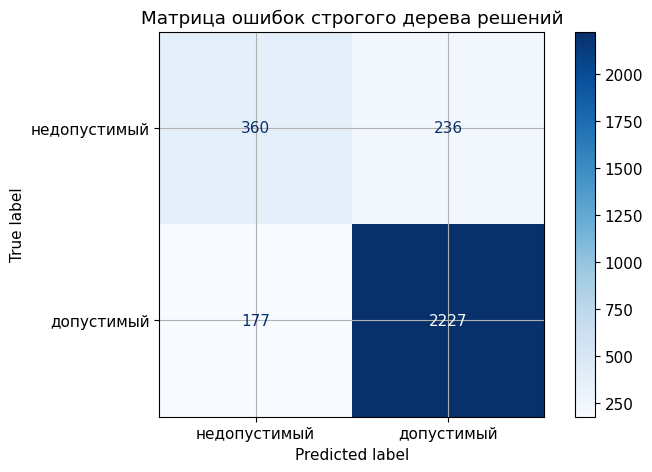

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=["недопустимый", "допустимый"])
disp.plot(values_format="d", cmap="Blues")
plt.title("Матрица ошибок строгого дерева решений")
plt.show()


In [7]:
label_candidates = ["mode_label", "class_label", "fault_label", "fault_code"]
available_label_columns = [column for column in label_candidates if column in diagnostics_df.columns]

test_error_details = model_df.loc[test_idx, ["sample_id", classification_target]].copy()
test_error_details["true_class"] = y_test
test_error_details["predicted_class"] = y_pred
test_error_details["error_type"] = np.select(
    [
        (test_error_details["true_class"] == 0) & (test_error_details["predicted_class"] == 1),
        (test_error_details["true_class"] == 1) & (test_error_details["predicted_class"] == 0),
        test_error_details["true_class"] == test_error_details["predicted_class"],
    ],
    ["false_allowed", "false_blocked", "correct"],
    default="other",
)

if available_label_columns:
    test_error_details = test_error_details.merge(
        diagnostics_df[["sample_id"] + available_label_columns],
        on="sample_id",
        how="left",
        validate="one_to_one",
    )
    summary_column = available_label_columns[0]
    error_summary = (
        test_error_details.groupby([summary_column, "error_type"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
else:
    error_summary = test_error_details["error_type"].value_counts().to_frame("count")

error_summary


error_type,correct,false_allowed,false_blocked
class_label,,,
high_target_temperature,360,236,0
normal_or_moderate_target_temperature,2227,0,177


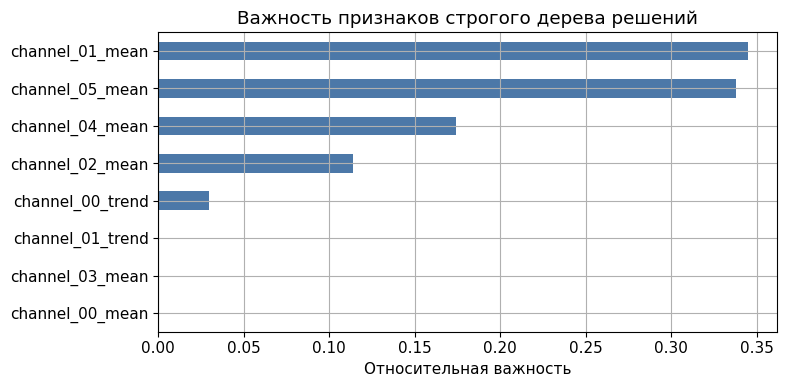

,importance
channel_00_mean,0.000000
channel_03_mean,0.000000
channel_01_trend,0.000000
channel_00_trend,0.029557
channel_02_mean,0.114128
channel_04_mean,0.173948
channel_05_mean,0.337724
channel_01_mean,0.344643


In [8]:
importance = pd.Series(tree_model.feature_importances_, index=classification_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_xlabel("Относительная важность")
ax.set_title("Важность признаков строгого дерева решений")
plt.tight_layout()
plt.show()
importance.to_frame("importance")


## Демонстрация риска утечки данных

Если в классификацию включить столбцы, из которых непосредственно построена
целевая переменная, дерево будет воспроизводить правило разметки, а не решать
независимую прогностическую задачу.


In [9]:
leakage_features = [column for column in ['channel_00_mean', 'channel_01_mean', 'channel_02_mean', 'channel_03_mean', 'channel_04_mean', 'channel_05_mean', 'target_temperature_c'] if column in full_df.columns]
leakage_df = full_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=leakage_features + [classification_target]
).copy()
if len(leakage_features) >= 2 and leakage_df[classification_target].nunique() == 2:
    train_idx_l, test_idx_l, _ = group_holdout_split(leakage_df, GROUP_COLUMN, test_share=0.25)
    leakage_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=8, random_state=RANDOM_STATE)
    leakage_tree.fit(leakage_df.loc[train_idx_l, leakage_features], leakage_df.loc[train_idx_l, classification_target].astype(int))
    leakage_pred = leakage_tree.predict(leakage_df.loc[test_idx_l, leakage_features])
    leakage_metrics = pd.Series(
        classification_metrics(leakage_df.loc[test_idx_l, classification_target].astype(int), leakage_pred),
        name="leakage_demo",
    )
else:
    leakage_metrics = pd.Series(dtype=float, name="leakage_demo")
leakage_metrics.to_frame("value")


,value
accuracy,0.999333
precision_not_allowed,0.996656
recall_not_allowed,1.000000
f1_not_allowed,0.998325
dangerous_false_allowed_rate,0.000000


In [10]:
experiment_depth = 3
experiment_tree = DecisionTreeClassifier(max_depth=experiment_depth, min_samples_leaf=8, random_state=RANDOM_STATE)
experiment_tree.fit(X_train, y_train)
experiment_pred = experiment_tree.predict(X_test)
pd.Series(classification_metrics(y_test, experiment_pred), name="experiment")


accuracy                        0.862333
precision_not_allowed           0.670391
recall_not_allowed              0.604027
f1_not_allowed                  0.635481
dangerous_false_allowed_rate    0.395973
Name: experiment, dtype: float64

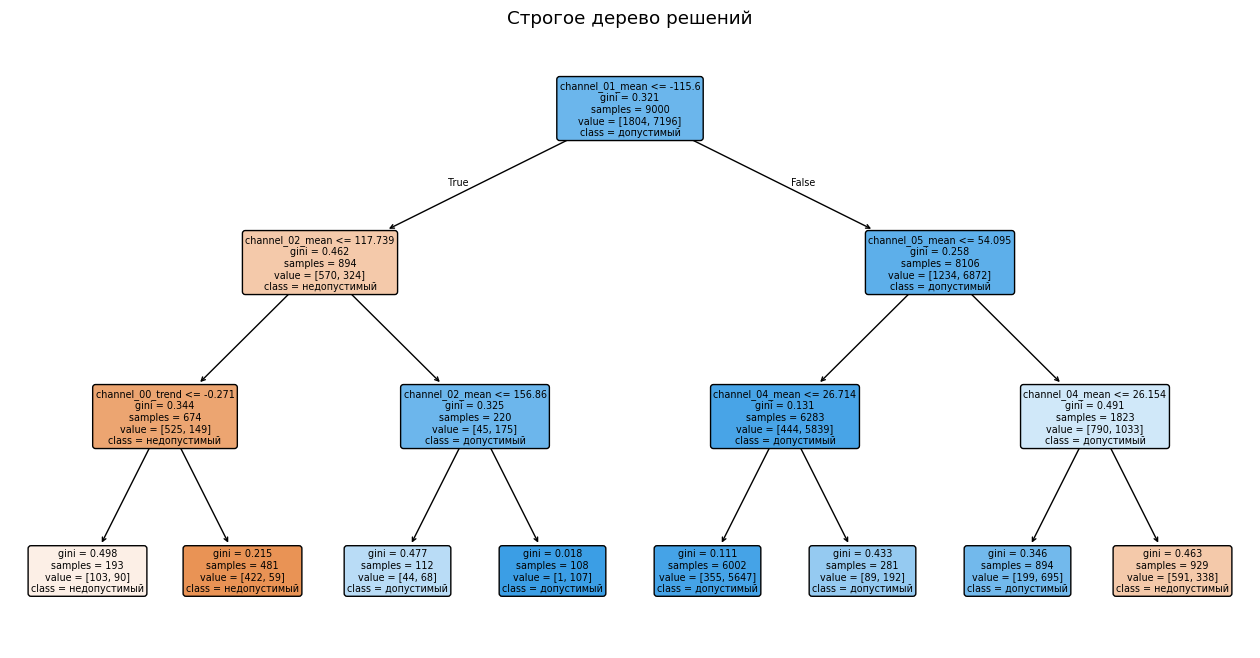

In [11]:
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=classification_features,
    class_names=["недопустимый", "допустимый"],
    filled=True,
    rounded=True,
    impurity=True,
)
plt.title("Строгое дерево решений")
plt.show()


## Задание

1. Укажите целевую переменную, кодировку классов и физический смысл класса 0.
2. Сравните дерево решений с базовой моделью большинства.
3. Постройте матрицу ошибок и рассчитайте долю ложных разрешений.
4. Выпишите 2-3 правила дерева в инженерной форме.
5. Объясните, какие признаки были исключены из-за риска утечки данных.
